In [ ]:
# =====================================================
# INSTALL LIBRARY (jalankan sekali saja)
# =====================================================

!pip install -q tensorflow openpyxl scikit-learn

DATASET FAKTUR SPAREPART BENGKEL
Jumlah Data   : 170
Jumlah Kolom  : 9

Daftar Kolom:
• Tanggal
• No. Faktur
• Supplier
• Nama Barang
• Qty
• Harga Satuan
• Bruto
• Diskon (%)
• Netto


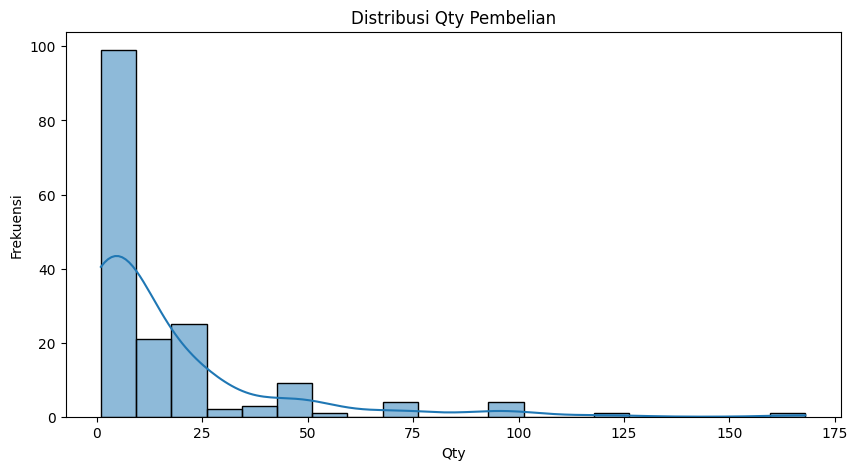

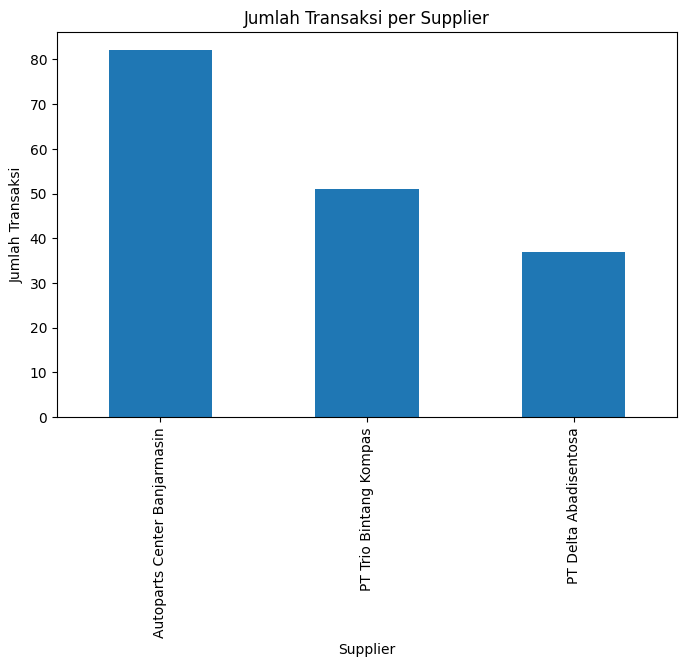

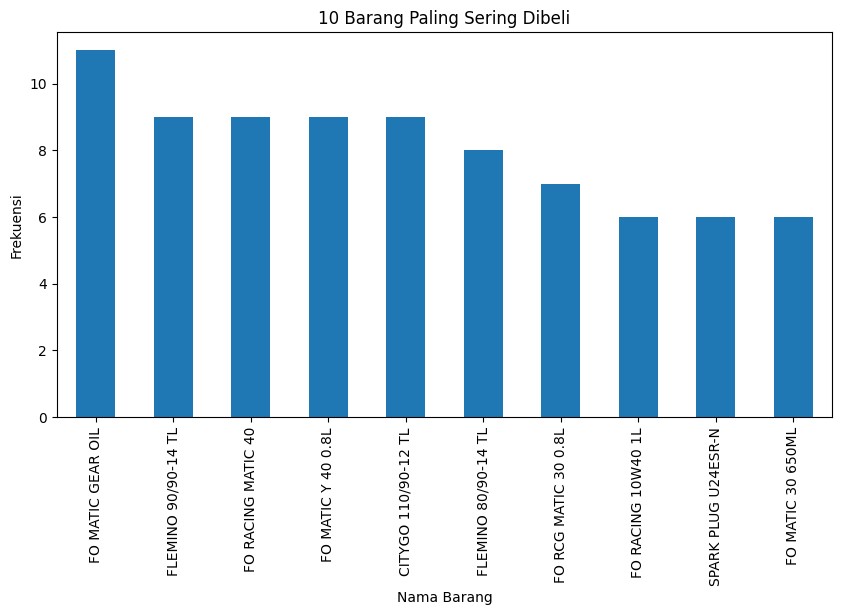

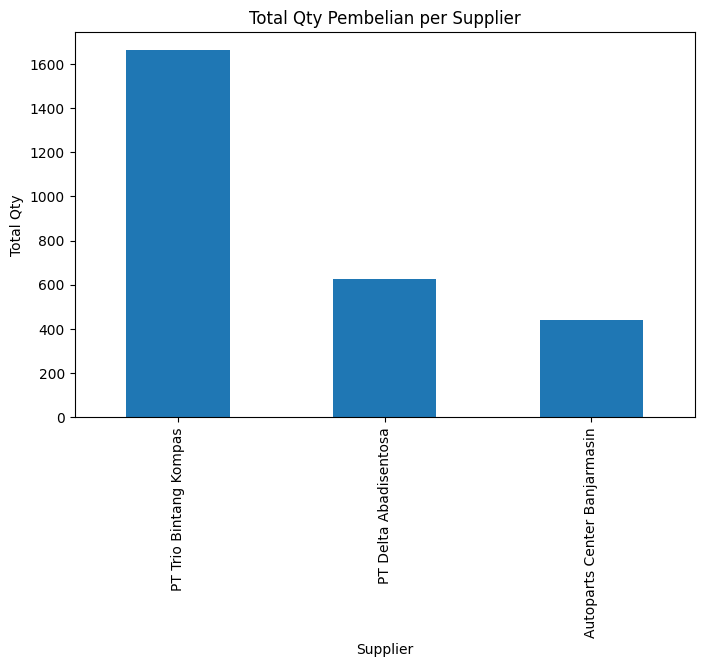

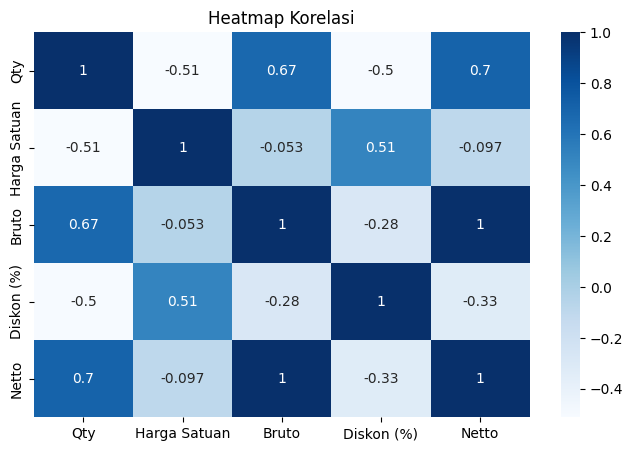


Shape Setelah Encoding : (170, 68)

Jumlah Data Training : 136
Jumlah Data Testing  : 34


ARSITEKTUR MODEL ANN


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 64)             │         4,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,041 (27.50 KB)

 Trainable params: 7,041 (27.50 KB)

 Non-trainable params: 0 (0.00 B)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


HASIL EVALUASI MODEL


,Metrik,Nilai
0,MAE,5.0100
1,RMSE,9.2900
2,R²,0.7408




20 DATA PREDIKSI PERTAMA


,Aktual,Prediksi,Error,Error Absolut
0,15,29.0,-14.0,14.0
1,3,2.0,1.0,1.0
2,24,25.0,-1.0,1.0
3,4,2.0,2.0,2.0
4,1,1.0,0.0,0.0
5,24,39.0,-15.0,15.0
6,20,22.0,-2.0,2.0
7,1,8.0,-7.0,7.0
8,24,26.0,-2.0,2.0
9,2,2.0,0.0,0.0


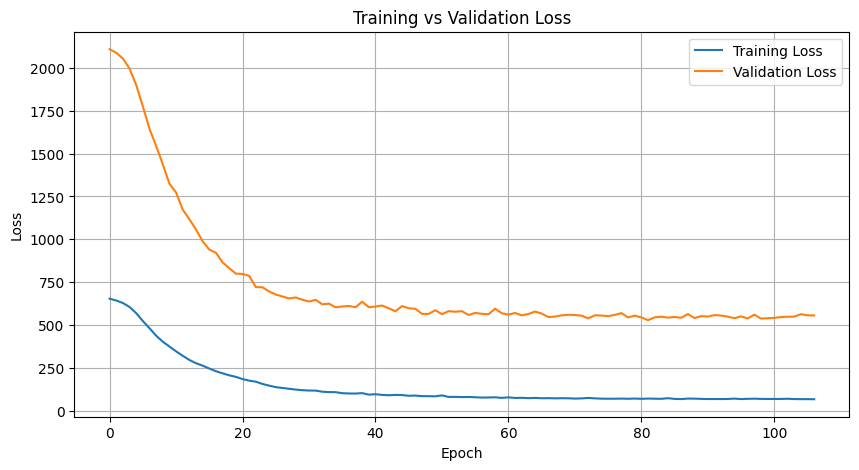

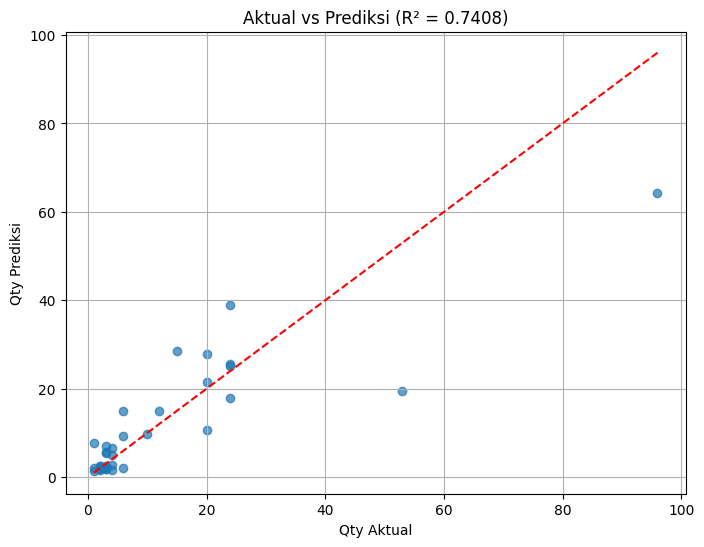

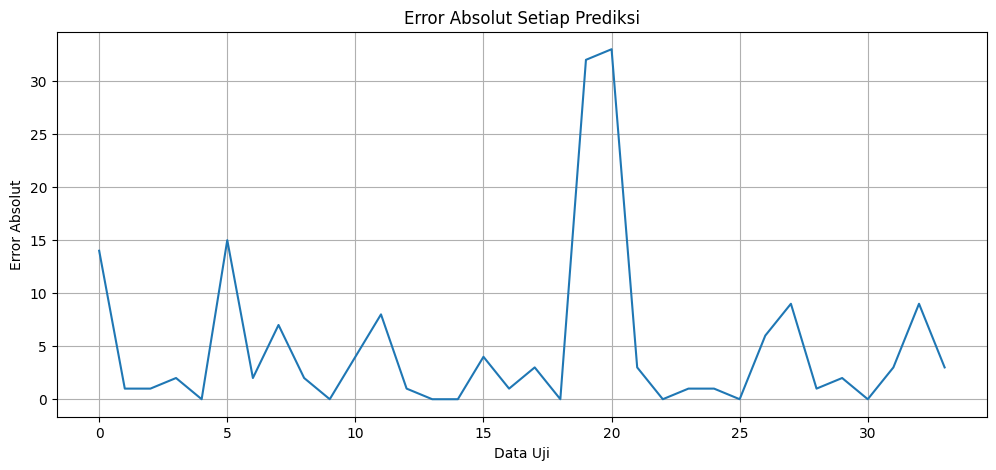



RINGKASAN HASIL
MAE  : 5.01
RMSE : 9.29
R²   : 0.7408


In [ ]:
# ==========================================================
# IMPORT LIBRARY
# ==========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import ColumnTransformer

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping

# ==========================================================
# LOAD DATASET
# ==========================================================

df = pd.read_excel(
    "Dataset_Faktur_Sparepart_Berkah_Bunda_Motor.xlsx"
)

# ==========================================================
# INFORMASI DATASET
# ==========================================================

print("="*80)
print("DATASET FAKTUR SPAREPART BENGKEL")
print("="*80)

print(f"Jumlah Data   : {len(df)}")
print(f"Jumlah Kolom  : {len(df.columns)}")

print("\nDaftar Kolom:")

for col in df.columns:
    print("•", col)

# ==========================================================
# FEATURE ENGINEERING
# ==========================================================

df["Tanggal"] = pd.to_datetime(df["Tanggal"])

df["Bulan"] = df["Tanggal"].dt.month
df["Tahun"] = df["Tanggal"].dt.year

# ==========================================================
# VISUALISASI 1
# DISTRIBUSI QTY
# ==========================================================

plt.figure(figsize=(10,5))

sns.histplot(
    df["Qty"],
    bins=20,
    kde=True
)

plt.title("Distribusi Qty Pembelian")
plt.xlabel("Qty")
plt.ylabel("Frekuensi")

plt.show()

# ==========================================================
# VISUALISASI 2
# DISTRIBUSI SUPPLIER
# ==========================================================

plt.figure(figsize=(8,5))

df["Supplier"].value_counts().plot(
    kind="bar"
)

plt.title("Jumlah Transaksi per Supplier")
plt.xlabel("Supplier")
plt.ylabel("Jumlah Transaksi")

plt.show()

# ==========================================================
# VISUALISASI 3
# TOP 10 BARANG PALING SERING DIBELI
# ==========================================================

plt.figure(figsize=(10,5))

df["Nama Barang"] \
.value_counts() \
.head(10) \
.plot(kind="bar")

plt.title("10 Barang Paling Sering Dibeli")
plt.ylabel("Frekuensi")

plt.show()

# ==========================================================
# VISUALISASI 4
# TOTAL QTY PER SUPPLIER
# ==========================================================

plt.figure(figsize=(8,5))

df.groupby("Supplier")["Qty"] \
.sum() \
.sort_values(ascending=False) \
.plot(kind="bar")

plt.title("Total Qty Pembelian per Supplier")
plt.ylabel("Total Qty")

plt.show()

# ==========================================================
# VISUALISASI 5
# HEATMAP KORELASI
# ==========================================================

plt.figure(figsize=(8,5))

corr = df[
    [
        "Qty",
        "Harga Satuan",
        "Bruto",
        "Diskon (%)",
        "Netto"
    ]
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues"
)

plt.title("Heatmap Korelasi")

plt.show()

# ==========================================================
# INPUT DAN TARGET
# ==========================================================

X = df[
    [
        "Supplier",
        "Nama Barang",
        "Harga Satuan",
        "Diskon (%)",
        "Bulan",
        "Tahun"
    ]
]

y = df["Qty"]

# ==========================================================
# PREPROCESSING
# ==========================================================

categorical_features = [
    "Supplier",
    "Nama Barang"
]

numerical_features = [
    "Harga Satuan",
    "Diskon (%)",
    "Bulan",
    "Tahun"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            MinMaxScaler(),
            numerical_features
        )
    ]
)

X_processed = preprocessor.fit_transform(X)
X_processed = X_processed.toarray()

print("\nShape Setelah Encoding :", X_processed.shape)

# ==========================================================
# SPLIT DATA
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y,
    test_size=0.2,
    random_state=42
)

print("\nJumlah Data Training :", len(X_train))
print("Jumlah Data Testing  :", len(X_test))

# ==========================================================
# MEMBANGUN MODEL ANN
# ==========================================================

model = Sequential([

    Input(shape=(X_train.shape[1],)),

    Dense(
        64,
        activation="relu"
    ),

    Dense(
        32,
        activation="relu"
    ),

    Dense(
        16,
        activation="relu"
    ),

    Dense(
        1,
        activation="relu"
    )

])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

# ==========================================================
# ARSITEKTUR MODEL
# ==========================================================

print("\n")
print("="*80)
print("ARSITEKTUR MODEL ANN")
print("="*80)

model.summary()

# ==========================================================
# TRAINING
# ==========================================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=25,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=500,
    batch_size=8,
    callbacks=[early_stop],
    verbose=0
)

# ==========================================================
# PREDIKSI
# ==========================================================

y_pred = model.predict(X_test).flatten()

# ==========================================================
# EVALUASI
# ==========================================================

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

# ==========================================================
# HASIL EVALUASI
# ==========================================================

hasil_evaluasi = pd.DataFrame({
    "Metrik":[
        "MAE",
        "RMSE",
        "R²"
    ],
    "Nilai":[
        round(mae,2),
        round(rmse,2),
        round(r2,4)
    ]
})

print("\n")
print("="*80)
print("HASIL EVALUASI MODEL")
print("="*80)

display(
    hasil_evaluasi
)

# ==========================================================
# TABEL PREDIKSI
# ==========================================================

hasil = pd.DataFrame({
    "Aktual": y_test.values,
    "Prediksi": np.round(y_pred,0)
})

hasil["Error"] = (
    hasil["Aktual"] -
    hasil["Prediksi"]
)

hasil["Error Absolut"] = (
    hasil["Error"]
).abs()

print("\n")
print("="*80)
print("20 DATA PREDIKSI PERTAMA")
print("="*80)

display(
    hasil.head(20)
)

# ==========================================================
# VISUALISASI 6
# TRAINING VS VALIDATION LOSS
# ==========================================================

plt.figure(figsize=(10,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.grid(True)

plt.show()

# ==========================================================
# VISUALISASI 7
# AKTUAL VS PREDIKSI
# ==========================================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--'
)

plt.xlabel("Qty Aktual")
plt.ylabel("Qty Prediksi")

plt.title(
    f"Aktual vs Prediksi (R² = {r2:.4f})"
)

plt.grid(True)

plt.show()

# ==========================================================
# VISUALISASI 8
# ERROR ABSOLUT
# ==========================================================

hasil_sorted = hasil.reset_index(drop=True)

plt.figure(figsize=(12,5))

plt.plot(
    hasil_sorted["Error Absolut"]
)

plt.title(
    "Error Absolut Setiap Prediksi"
)

plt.xlabel("Data Uji")
plt.ylabel("Error Absolut")

plt.grid(True)

plt.show()

# ==========================================================
# RINGKASAN AKHIR
# ==========================================================

print("\n")
print("="*80)
print("RINGKASAN HASIL")
print("="*80)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")